<a href="https://colab.research.google.com/github/hsozpa/aidev/blob/main/Lesson13/%E5%A4%9A%E5%80%A4%E5%88%86%E9%A1%9E.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 必要なライブラリのimport
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical

In [ ]:
# データの読み込み
(X_train, Y_train),(X_test, Y_test) = tf.keras.datasets.cifar10.load_data()
class_names = ['airplane','car','bird','cat','deer','dog','frog','horse','ship','truck']

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step


In [ ]:
# 正規化、onehot化
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0
Y_train = to_categorical(Y_train,10)
Y_test = to_categorical(Y_test,10)

In [ ]:
# モデル構築
model = tf.keras.Sequential([
    tf.keras.Input(shape=(32, 32, 3)),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

In [ ]:
#コンパイル
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy']
              )

In [ ]:
# モデルの構造を表示
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
%%time
# 学習

log = model.fit(
    X_train, Y_train,
    epochs=5000,
    batch_size=64,
    verbose=True,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            min_delta=0,
            patience=50,
            verbose=1,
            restore_best_weights=True
        )
    ],
    validation_data=(X_test, Y_test)
)

Epoch 1/5000
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.3576 - loss: 1.7582 - val_accuracy: 0.5543 - val_loss: 1.2622
Epoch 2/5000
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5790 - loss: 1.1960 - val_accuracy: 0.6136 - val_loss: 1.1094
Epoch 3/5000
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6334 - loss: 1.0440 - val_accuracy: 0.6362 - val_loss: 1.0324
Epoch 4/5000
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6657 - loss: 0.9645 - val_accuracy: 0.6610 - val_loss: 0.9657
Epoch 5/5000
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6930 - loss: 0.8904 - val_accuracy: 0.6642 - val_loss: 0.9659
Epoch 6/5000
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7122 - loss: 0.8267 - val_accuracy: 0.6762 - val_loss: 0.9478
Epoch 7/5000
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7263 - loss: 0.7884 - val_accuracy: 0.6985 - val_loss: 0.8812
Epoch 8/5000
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7468 - loss: 0.7327 -

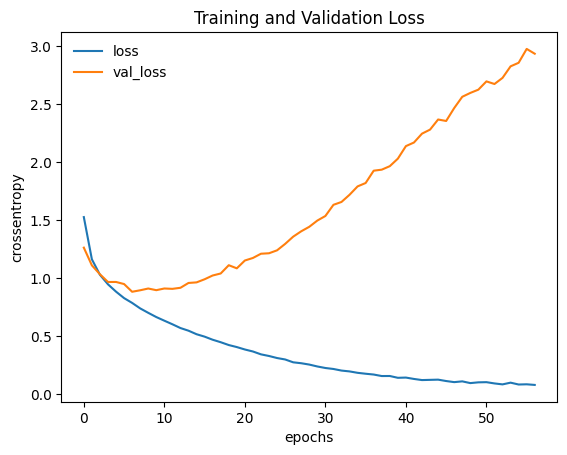

In [ ]:
# グラフ表示
plt.plot(log.history['loss'], label='loss')
plt.plot(log.history['val_loss'], label='val_loss')
plt.legend(frameon=False)
plt.xlabel("epochs")
plt.ylabel("crossentropy")
plt.title("Training and Validation Loss")
plt.show()

In [ ]:
# predictで予測を行なう
Y_pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
Y_pred

array([[7.39940500e-04, 5.70280303e-04, 3.74164316e-03, ...,
        2.19740959e-05, 1.06556620e-02, 4.44280886e-04],
       [7.31249675e-02, 3.37150365e-01, 4.79153205e-05, ...,
        1.20681998e-05, 5.26660085e-01, 6.28587529e-02],
       [9.78889018e-02, 1.19635813e-01, 3.89382103e-03, ...,
        5.80156082e-03, 6.23373628e-01, 1.29523903e-01],
       ...,
       [4.58275230e-04, 9.17478701e-06, 1.42620638e-01, ...,
        3.10012344e-02, 2.68942367e-05, 8.30790577e-06],
       [1.74403796e-03, 9.42542553e-01, 1.23506517e-03, ...,
        1.40875185e-04, 9.45275387e-05, 1.32647727e-03],
       [1.00656776e-04, 1.06695428e-04, 7.30593980e-04, ...,
        9.70228672e-01, 1.19360575e-05, 1.63202043e-04]], dtype=float32)

In [ ]:
# 最も確率の高いクラスを取り出す
Y_pred_classes = np.argmax(Y_pred, axis=1)

# 正解ラベルも同じ形式に（one-hot → インデックスへ）
Y_true_classes = np.argmax(Y_test, axis=1)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(Y_true_classes, Y_pred_classes, target_names=class_names))

cm = confusion_matrix(Y_true_classes, Y_pred_classes)
print(cm)

              precision    recall  f1-score   support

    airplane       0.70      0.79      0.74      1000
         car       0.83      0.80      0.81      1000
        bird       0.67      0.49      0.56      1000
         cat       0.51      0.53      0.52      1000
        deer       0.65      0.64      0.64      1000
         dog       0.55      0.68      0.61      1000
        frog       0.78      0.78      0.78      1000
       horse       0.82      0.68      0.74      1000
        ship       0.80      0.81      0.80      1000
       truck       0.74      0.80      0.77      1000

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.70     10000
weighted avg       0.70      0.70      0.70     10000

[[788  18  25  13  18  14   9   6  64  45]
 [ 21 803   7   6   2   8  12   0  28 113]
 [ 94  11 487  78 106 120  55  22  17  10]
 [ 22  13  39 529  75 206  49  24  22  21]
 [ 33   2  60  83 641  47  60  53  16   5]
 [ 25   3  33 157  36 678 